In [1]:
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from scipy.ndimage import maximum_filter1d, uniform_filter1d
from scipy.interpolate import interp1d
from scipy.io import savemat

In [ ]:
ENVELOPE_FRAME_MS = 10

# cycle wise envelope
# phase grid


def extract_envelope(
    y: np.ndarray,
    sr: int,
    frame_ms: float = ENVELOPE_FRAME_MS,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Sliding max |amplitude| (hop = 1 sample), then moving-average smooth."""
    
    
    window_size = max(1, int(frame_ms / 1000 * sr))
    abs_y = np.abs(y)
    n = len(abs_y) 

    # envelope_raw = np.zeros(n)
    # for i in range(n):
    #     low=max(0,i-window_size//2)
    #     high=min(len(abs_y),i+window_size//2)
    #     envelope_raw[i] = np.max(abs_y[low:high])

    
    # envelope_mean = np.zeros(n)
    # for i in range(n):
    #     low=max(0,i-window_size//2)
    #     high=min(len(abs_y),i+window_size//2)
    #     envelope_mean[i] = np.mean(envelope_raw[low:high])
    
    envelope_raw = maximum_filter1d(abs_y, size=window_size, mode="reflect")
    envelope_smooth = uniform_filter1d(envelope_raw, size=window_size, mode="reflect")
    time = np.arange(n) / sr

    return time, envelope_raw, envelope_smooth

In [ ]:
from pathlib import Path

audio_dir = "/itf-fi-ml/home/sagardu/djembe_drive/Data/DD_MultiM_Proc/AudioVideo_proc"
sub_dirs = sorted(d for d in os.listdir(audio_dir) if d.startswith("BKO"))

piece_valid = {"manjanin", "suku", "wasulunka", "maraka"}
valid = {"M-Dun", "M-Jem-1", "M-Jem-2", "P-Dun", "P-Jem-1", "P-Jem-2"}

envelopes = {}

for sub_dir in sub_dirs:
    sub_dir_path = os.path.join(audio_dir, sub_dir)

    for file in os.listdir(sub_dir_path):
        if not file.lower().endswith(".wav"):
            continue
        parts = file.split("_")
        if len(parts) <= 5:
            continue
        rhythm = os.path.splitext(parts[4])[0].lower()
        label = os.path.splitext(parts[5])[0]
        if label not in valid or rhythm not in piece_valid:
            continue

        piece_id = "_".join(parts[:5])  # e.g. BKO_E1_D1_01_Suku
        audio_path = os.path.join(sub_dir_path, file)
        y, sr = librosa.load(audio_path, sr=None)
        time, envelope_raw, envelope_smooth = extract_envelope(y, sr)

        envelopes.setdefault(piece_id, {})[label] = {
            "time": time,
            "envelope": envelope_smooth,
            "sr": sr,
        }

for piece_id, labels in envelopes.items():
    if len(labels) != 6:
        print(f"WARNING: {piece_id} has {len(labels)} labels: {sorted(labels)}")

print(f"Processed {len(envelopes)} pieces, {sum(len(v) for v in envelopes.values())} drum tracks")

out_dir = Path("data/drum_envelope")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "all_drum_envelopes.mat"
savemat(out_path, envelopes)
print(f"Saved -> {out_path}")

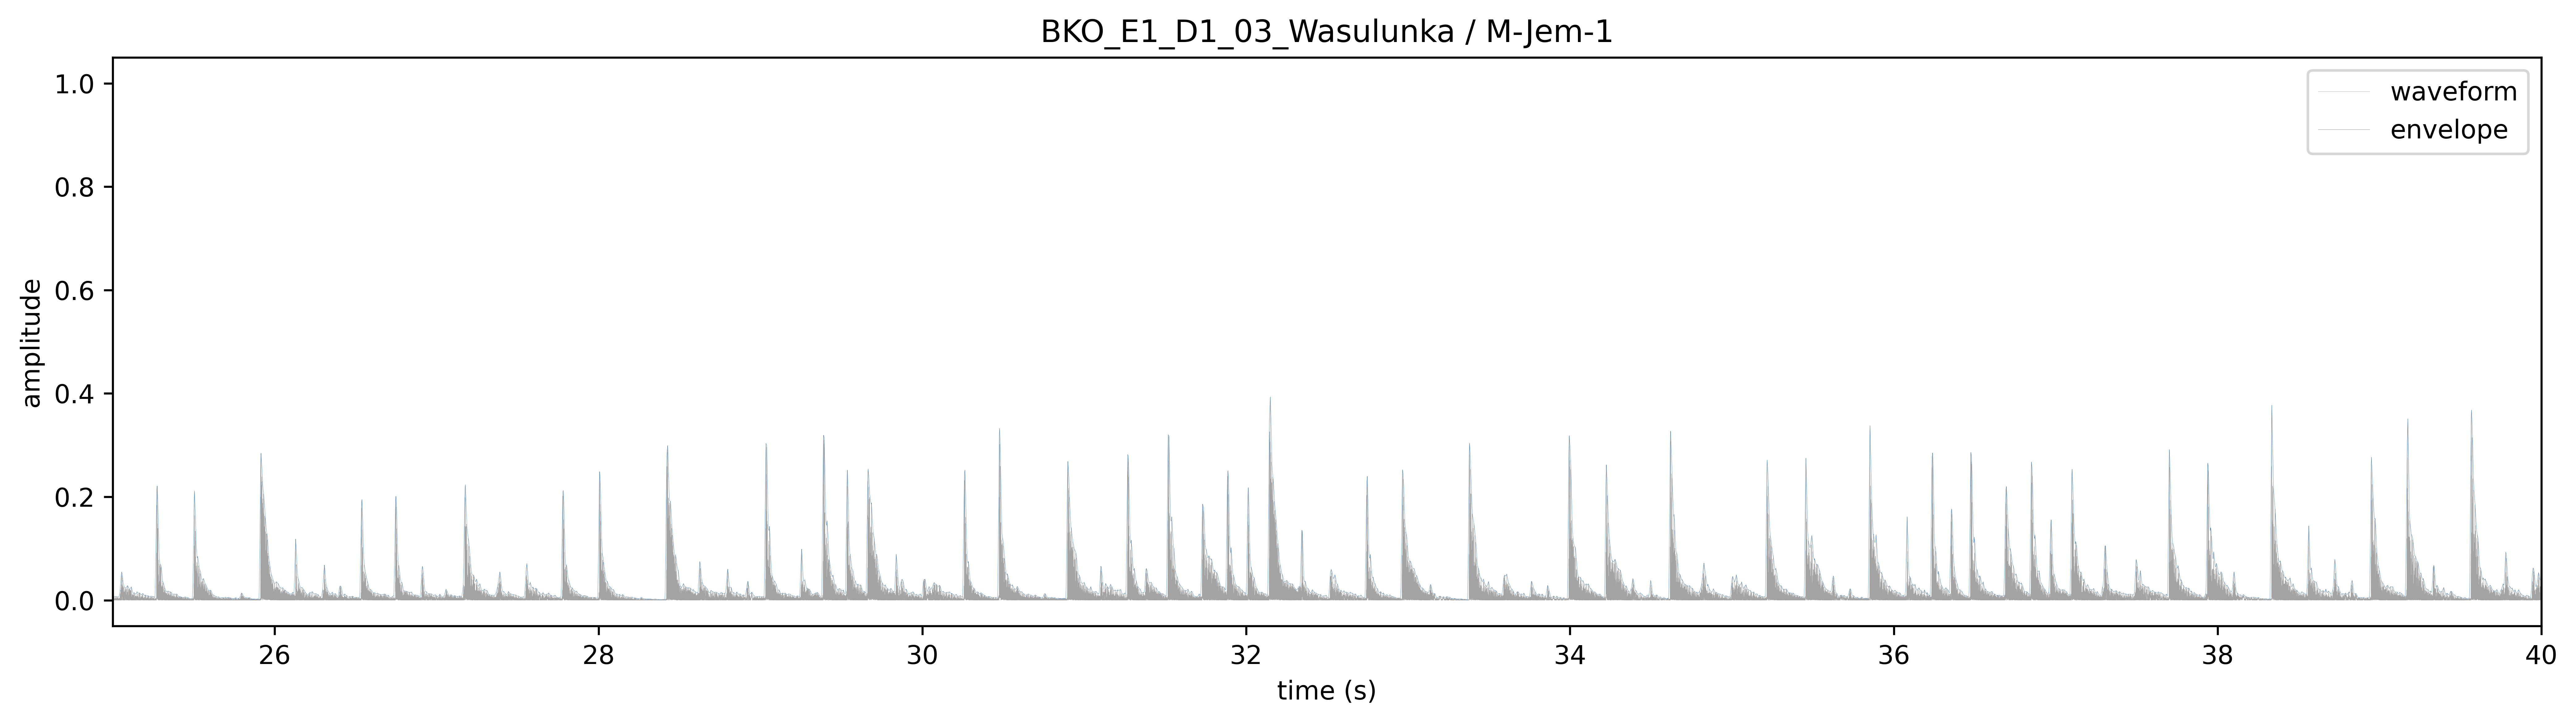

In [10]:
from scipy.io import loadmat

piece_id = "BKO_E1_D1_03_Wasulunka"
label = "M-Jem-1"
audio_dir = "/itf-fi-ml/home/sagardu/djembe_drive/Data/DD_MultiM_Proc/AudioVideo_proc"

sub_dir = "_".join(piece_id.split("_")[:3])
audio_path = f"{audio_dir}/{sub_dir}/{piece_id}_{label}.wav"

mat_file = loadmat(f"data/drum_envelope/{piece_id}.mat")
label_data = mat_file[label][0, 0]
time = label_data["time"].squeeze()
envelope = label_data["envelope"].squeeze()

y, sr = librosa.load(audio_path, sr=None)
t_wav = np.arange(len(y)) / sr

# downsample for plotting (full signal is too dense to render)

fig, ax = plt.subplots(figsize=(14, 4), dpi=600)
ax.plot(t_wav, np.abs(y), color="0.55", linewidth=0.1, alpha=0.8, label="waveform")
ax.plot(time, envelope, color="steelblue", linewidth=0.1, label="envelope")
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.set_title(f"{piece_id} / {label}")
ax.legend(loc="upper right")
ax.set_xlim(25,40)
plt.tight_layout()

In [ ]:
import pickle

import pandas as pd

with open("data/drum_envelope/cluster_drum_envelope_08jun.pkl", "rb") as f:
    drum_env = pickle.load(f)
    


piece: BKO_E1_D1_01_Suku
drum cycles: 289
bvh cluster cycles (same piece): 289
match: True
metadata rows equal: True
piece: BKO_E1_D1_02_Maraka
drum cycles: 201
bvh cluster cycles (same piece): 201
match: True
metadata rows equal: True
piece: BKO_E1_D1_03_Wasulunka
drum cycles: 200
bvh cluster cycles (same piece): 200
match: True
metadata rows equal: True
piece: BKO_E1_D1_06_Manjanin
drum cycles: 382
bvh cluster cycles (same piece): 382
match: True
metadata rows equal: True
piece: BKO_E1_D1_07_Suku
drum cycles: 86
bvh cluster cycles (same piece): 86
match: True
metadata rows equal: True
piece: BKO_E1_D1_08_Suku
drum cycles: 82
bvh cluster cycles (same piece): 82
match: True
metadata rows equal: True
piece: BKO_E1_D2_03_Suku
drum cycles: 148
bvh cluster cycles (same piece): 148
match: True
metadata rows equal: True
piece: BKO_E1_D2_04_Maraka
drum cycles: 97
bvh cluster cycles (same piece): 97
match: True
metadata rows equal: True
piece: BKO_E1_D2_05_Wasulunka
drum cycles: 242
bvh cluste

In [5]:
import pickle

with open("data/drum_envelope/cluster_drum_envelope_08jun.pkl", "rb") as f:
    drum_env = pickle.load(f)

n_cycles, n_drums, n_phase = drum_env["envelopes"].shape
drum_labels = [str(x) for x in drum_env["drum_labels"]]

print(f"keys: {sorted(drum_env.keys())}")
print(f"envelopes shape: {drum_env['envelopes'].shape}  (n_cycles, n_drums, n_phase)")
print(f"phase grid: {drum_env['phase_grid'][0]:.2f} .. {drum_env['phase_grid'][-1]:.2f}  (n={len(drum_env['phase_grid'])})")
print(f"drum labels: {drum_labels}")
print(f"total cycles: {n_cycles}")
print(f"unique pieces: {len(set(drum_env['file_name']))}")
print(f"dance modes: {sorted(set(drum_env['dmode_name']))}")
print(f"metadata length check: {len(drum_env['file_name']) == n_cycles}")
print(f"envelope range: [{drum_env['envelopes'].min():.4f}, {drum_env['envelopes'].max():.4f}]")

keys: ['cycle_end', 'cycle_frame_times', 'cycle_idx', 'cycle_start', 'day', 'dmode_end', 'dmode_name', 'dmode_seg_idx', 'dmode_start', 'drum_labels', 'ensemble', 'envelopes', 'file_name', 'location', 'phase_grid', 'piece', 'rec_no']
envelopes shape: (5533, 6, 101)  (n_cycles, n_drums, n_phase)
phase grid: 0.00 .. 1.00  (n=101)
drum labels: ['M-Dun', 'M-Jem-1', 'M-Jem-2', 'P-Dun', 'P-Jem-1', 'P-Jem-2']
total cycles: 5533
unique pieces: 33
dance modes: ['audience', 'group', 'individual']
metadata length check: True
envelope range: [0.0001, 1.0000]
